# Notebook 7 – AC electricity consumption downscaling

This notebook downscales projected AC electricity consumption from a single city-level datapoint (NUTS region) to finer spatial units (CAPs and Municipi) for future years (2030, 2040, 2050). It combines gridded heat hazard, AC coverage, and population projections to produce scenario-specific maps and summary tables of AC use.

## Purpose

- Convert NUTS-level AC electricity use (kWh per AC user per year) into spatially explicit estimates.
- Produce CAP-level and Municipio-level indicators of:
  - AC consumption per AC user (kWh/user/yr)
  - AC consumption per capita (kWh/cap/yr)
  - Total AC electricity use (GWh/yr)
- Ensure consistency with:
  - City-wide AC penetration/ownership targets from Notebook 5
  - Population / exposure scenarios from the exposure manifest
  - City-level AC kWh/user values from the NUTS CSV.

## Inputs

- City configuration from `configs/<city>.yml` (AC settings, SSP scenario, NUTS ID, years).
- Ref grid and city mask (`template_ref.tif`, `city_mask.tif`) from previous notebooks.
- Gridded T2M hazard stack (`t2m_hazard_2030_2100_*.npz`) from Notebook 3.
- AC coverage maps by year (`ac_coverage_maps_<slug>.npz`) and city-level AC shares from Notebook 5.
- Population and age structure on the reference grid:
  - Baseline grids (`pop_on_ref`, `age_on_ref`) and
  - Scenario grids by year read from `exposure_manifest.json`.
- CAP and Municipio data:
  - CAP raster on ref grid (`cap_on_ref`) and CAP polygons/LUTs from Notebook 6.
  - Municipio raster (`muni_on_ref`) and Municipio polygons from the regions geopackage.
- NUTS-level AC electricity CSV (kWh per AC user per year) for the chosen SSP and NUTS ID.

## Method (core steps)

1. **City-level AC use:**  
   Read the NUTS CSV, select the configured NUTS ID and SSP scenario, and extract kWh per AC user for the target years. Save a small city-level time series.

2. **CAP-level per-user variation (hazard-based):**  
   - Compute a population-weighted heat hazard index per CAP using the T2M stack and population grids.  
   - Draw one random “effect” per CAP (fixed across years) from a normal distribution.  
   - For each year, create CAP-level kWh per AC user values as deviations around the city mean, with dispersion scaled by the ratio of local CAP hazard to the city-wide hazard.  
   - Rescale the CAP values so that the users-weighted city mean exactly matches the NUTS kWh per AC user for that year.

3. **Grid-level consumption and CAP aggregation:**  
   - Paint CAP-level per-user values back to the reference grid.  
   - Combine with AC coverage and population grids to obtain:
     - kWh per AC user (grid),
     - kWh per capita (grid),
     - total kWh (grid).  
   - Aggregate to CAPs to obtain:
     - AC share (users/pop),
     - kWh per AC user (CAP),
     - kWh per capita (CAP),
     - total kWh (CAP).

4. **Municipio aggregation:**  
   - Using the Municipio raster and polygons, aggregate pixel-level results to Municipi.  
   - Compute the same indicators (AC share, per-user, per-capita, total kWh) and verify that Municipi + “outside Municipi” sum back to the city totals.

## Outputs

- **CAP-level:**
  - `*_cap_ac_consumption_summary.csv` – per CAP and year: population, AC share, kWh per AC user, kWh per capita, total kWh (and GWh).
  - `*_cap_ac_consumption_map.geojson` – CAP geometries with the same indicators for mapping.

- **Municipio-level:**
  - `*_muni_ac_consumption_summary.csv` – per Municipio and year: population, AC share, kWh per AC user, kWh per capita, total kWh (and GWh).
  - `*_muni_ac_consumption_map.geojson` – Municipio geometries with the same indicators for mapping.

- **Diagnostics & plots:**
  - City-level checks ensuring:
    - AC shares from the maps match the NB5 targets.
    - Users-weighted mean kWh per AC user equals the NUTS input values.
  - Ranking tables and maps showing spatial patterns in:
    - kWh per AC user,
    - kWh per capita,
    - total kWh across CAPs and Municipi.

## Interpretation notes

- **Per AC user vs per capita:**  
  - *Per AC user* maps show average AC electricity use among households that own AC.  
  - *Per capita* maps divide the same total AC use by the entire population, so they are roughly:  
    _kWh per capita ≈ AC ownership share × kWh per AC user_.  
  - CAPs or Municipi with low ownership but intense usage per user can look modest per capita, while areas with high ownership levels appear high on per-capita maps.

- **CAPs vs Municipi:**  
  Municipio indicators are population-weighted aggregates of the underlying pixel/CAP values falling inside each Municipio. Differences between per-capita rankings and total-kWh rankings reflect the combined effect of intensity and population size.

In [1]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [2]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [4]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [5]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path
import json 

# FUA / Regions paths
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."

lut = (
    pd.read_csv(muni_lut_csv)
    .assign(muni_id=lambda d: d["muni_id"].astype(int))
    .sort_values("muni_id")
)
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."

cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif" # T2M ref grid
mask_tif = INT / "city_mask.tif" # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
# T2M hazard stack on ref grid (mean daily T2M per year)
t2m_npz_path = _first_existing(
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    glob_pattern="t2m_hazard_2030_2100*.npz"
)
assert t2m_npz_path and t2m_npz_path.exists(), "Missing T2M hazard .npz (run NB3)."

npz = np.load(t2m_npz_path)
YEARS = npz["years"].astype(int) # (n_years,)
DATA = npz["data"].astype("float32") # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"T2M hazard grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"
H2050 = DATA[list(YEARS).index(2050)]
print("Loaded T2M hazard:", t2m_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage
# loading AC targets (city mean shares) produced by NB5 
targets_path = INT / f"ac_city_targets_{SLUG}.csv"
t = pd.read_csv(targets_path)
ac_city_by_year = dict(zip(t["year"].astype(int), t["ac_share"].astype(float)))

# loading AC coverage maps (CAP-based maps) produced by NB5 
cov_path = INT / f"ac_coverage_maps_{SLUG}.npz"
z = np.load(cov_path)
YEARS_COV = z["YEARS_AC"].astype(int).tolist()
year_to_k = {y: i for i, y in enumerate(YEARS_COV)}

coverage_base_3d = z["coverage_base_3d"].astype("float32")
coverage_policy_3d = z["coverage_policy_3d"].astype("float32")

def cov_base_for_year(y: int) -> np.ndarray:
    return coverage_base_3d[year_to_k[int(y)]]

def cov_policy_for_year(y: int) -> np.ndarray:
    return coverage_policy_3d[year_to_k[int(y)]]

# Population / CAP rasters
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"), "15-64": d["a15_64"].astype("float32"), "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:
            age["<15"] = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s:
            age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:
            age["65+"] = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print(
    "Loaded exposure:",
    f"\n pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
    f"\n age lt15: {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
    f"\n age 15-64: {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
    f"\n age 65+: {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# multi-year exposure (population / age) from exposure_manifest.json 
expo_manifest_path = INT / "exposure_manifest.json"

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

if expo_manifest_path.exists():
    with open(expo_manifest_path) as f:
        expo_manifest = json.load(f)

    scen_dict = expo_manifest.get("scenarios", {})

    # priority: explicit scenario.code in cfg (if present)
    scenario_cfg = (cfg or {}).get("scenario", {}) or {}
    SCEN_CODE = scenario_cfg.get("code")

    # exp_scenario from YAML 
    if not SCEN_CODE:
        SCEN_CODE = cfg.get("exp_scenario")

    # derive from AC SSP (as in NB5/6)
    if (not SCEN_CODE) or (SCEN_CODE not in scen_dict):
        ac_cfg = cfg.get("ac", {})
        ssp = ac_cfg.get("ssp", None)
        if ssp is not None:
            for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
                if cand in scen_dict:
                    SCEN_CODE = cand
                    break

    # final fallback: first available scenario
    if (not SCEN_CODE) or (SCEN_CODE not in scen_dict):
        SCEN_CODE = sorted(scen_dict.keys())[0]

    print(f"Using exposure scenario for AC population: {SCEN_CODE}")
    scen_rec = scen_dict[SCEN_CODE]

    for year_str, rec in scen_rec.items():
        y = int(year_str)

        ages_npz = np.load(rec["age_npz"])
        pop_npz  = np.load(rec["pop_npz"])

        age_on_ref_by_year[y] = {
            "<15":   ages_npz["lt15"].astype("float32"),
            "15-64": ages_npz["a15_64"].astype("float32"),
            "65+":   ages_npz["g65"].astype("float32"),
        }
        pop_on_ref_by_year[y] = pop_npz["pop"].astype("float32")

        # shape consistency
        assert pop_on_ref_by_year[y].shape == CITY_MASK.shape, f"pop grid {y} shape mismatch"
        for grp in ["<15", "15-64", "65+"]:
            assert age_on_ref_by_year[y][grp].shape == CITY_MASK.shape, f"age {grp} grid {y} shape mismatch"

    # baseline (for descriptive parts that still use pop_on_ref / age_on_ref)
    BASE_EXPO_YEAR = min(pop_on_ref_by_year.keys())
    age_on_ref_base = age_on_ref_by_year[BASE_EXPO_YEAR]
    pop_on_ref_base = pop_on_ref_by_year[BASE_EXPO_YEAR]

    # overwrite single-year variables to refer to the baseline year,
    # so all code that still uses age_on_ref / pop_on_ref stays consistent
    age_on_ref = age_on_ref_base
    pop_on_ref = pop_on_ref_base

    def pop_for_year(year: int) -> np.ndarray:
        year = int(year)
        if year not in pop_on_ref_by_year:
            raise KeyError(f"No population grid for year {year} in exposure scenario {SCEN_CODE}.")
        return pop_on_ref_by_year[year]

else:
    print("WARNING: exposure_manifest.json not found – AC notebook will reuse baseline pop_on_ref for all years.")

    def pop_for_year(year: int) -> np.ndarray:
        # fallback: always return baseline
        return pop_on_ref

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Optional: CAP_MASK from coverage NPZ if present, else derive from CAP raster
if "CAP_MASK" in z.files:
    CAP_MASK = z["CAP_MASK"].astype(bool)
else:
    CAP_MASK = (CITY_MASK & (cap_on_ref > 0))

# Vectors
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print(
    "Loaded:",
    "\n FUA:", fua_gpkg.name,
    "\n Regions:", regions_gpkg.name,
    "\n muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
    "\n CAPs:", cap_gpkg.name
)

Using muni LUT: genova_muni_lut.csv | rows: 10
Using CAP LUT: genova_cap_lut.csv | rows: 70
Using CAP WGS84 LUT: genova_cap_wgs84_lut.csv
Loaded T2M hazard: t2m_hazard_2030_2100_genova.npz | years: 2030 → 2050
Loaded exposure: 
 pop_on_ref: (251, 251), sum=576550 
 age lt15: (251, 251), sum=53034 
 age 15-64: (251, 251), sum=334769 
 age 65+: (251, 251), sum=188747
Using exposure scenario for AC population: SSP2
Loaded regions: 10 polygons; muni_on_ref shape: (251, 251)
Unique muni IDs on grid (>=0): 10
Loaded: 
 FUA: genova_fua.gpkg 
 Regions: genova_regions.gpkg 
 muni_on_ref: genova_muni_on_ref.tif (251, 251) 
 CAPs: genova_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [6]:
# AC kWh per AC-user (city) from NUTS CSV (no NetCDF / no pixel)
import pandas as pd
import numpy as np
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# numeric scenario from YAML
ssp_choice = int(ac_cfg.get("ssp", 2))          # 1,2,3,5
print(f"[AC kWh] Using scenario ssp = {ssp_choice} (from cfg['ac']['ssp'])")
years_interest = list(ac_cfg.get("years", [2030, 2040, 2050]))
nuts_id = ac_cfg.get("nuts_id", None)
assert nuts_id, "cfg['ac']['nuts_id'] missing (e.g. 'ITI43')."

cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

need = [COL_ID, COL_SSP, COL_YEAR, COL_VAL]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns in {kwh_path.name}: {missing}. Found: {list(df.columns)}"

def _scenario_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)   # so it handles "2" and "SSP2"
    return int(m.group(1)) if m else None

df = df.copy()
df["_scenario_int"] = df[COL_SSP].map(_scenario_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

sub = df[
    (df[COL_ID].astype(str) == str(nuts_id)) &
    (df["_scenario_int"] == ssp_choice)
].dropna(subset=[COL_YEAR, COL_VAL])

assert len(sub) > 0, (
    f"No rows found for NUTS_ID={nuts_id} and Scenario={ssp_choice} in {kwh_path.name}. "
    f"Check values in columns {COL_ID} / {COL_SSP}."
)

series = (sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean()).to_dict()

missing_years = [y for y in years_interest if int(y) not in series]
assert not missing_years, f"Missing years in AC kWh CSV for {nuts_id}, Scenario={ssp_choice}: {missing_years}"

per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}
per_user_city = float(per_user_city_by_year[max(years_interest)])

print("AC per-AC-user from NUTS CSV (kWh/user/yr):")
for y in years_interest:
    print(f" {y}: {per_user_city_by_year[int(y)]:.3f}")

ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[int(y)] for y in years_interest],
})

out_csv = INT / f"ac_per_user_city_{SLUG}.csv"
ac_city_series.to_csv(out_csv, index=False)
print("Saved:", out_csv)

[AC kWh] Using scenario ssp = 2 (from cfg['ac']['ssp'])
AC per-AC-user from NUTS CSV (kWh/user/yr):
 2030: 1574.514
 2040: 1662.144
 2050: 1739.301
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_per_user_city_genova.csv


**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [7]:
import numpy as np
import pandas as pd

# we now rely on per-year dict from the NetCDF step
assert ("per_user_city_by_year" in globals() and isinstance(per_user_city_by_year, dict) and len(per_user_city_by_year) > 0), \
 "per_user_city_by_year must be defined by the NetCDF/FUA selection cell."

years_interest = [2030, 2040, 2050]
cap_ids = cap_on_ref  # pop_grid will now be year-specific via pop_for_year

def _get_H_for_year(year):
    if year not in YEARS:
        raise KeyError(f"Year {year} not found in T2M YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """ Return AC coverage map for a given year from the NB5 3D maps.
    NB5 already did the year-specific calibration, so no extra rescaling here.
    """
    year = int(year)
    if year not in year_to_k:
        raise KeyError(f"Year {year} not in YEARS_COV (from NB5): {YEARS_COV}")
    base = cov_base_for_year(year).astype("float32")
    return np.clip(base, 0.0, 1.0).astype("float32")

rng = np.random.default_rng(42)
sigma0 = 0.20 # base dispersion (20% of mean)
gamma = 1.0 # how strongly dispersion scales with hazard ratio

**CAP Maps or tables:**

In [8]:
# drawing ONE eps per CAP ONCE, and reuse it for all years 
# Use 2030 only to define the CAP set (ids) consistently.
H0 = _get_H_for_year(2030)
pop_grid0 = pop_for_year(2030)  # NEW: 2030 population
CAP_PIX0 = CITY_MASK & np.isfinite(H0) & (cap_ids > 0)
valid0 = CAP_PIX0 & np.isfinite(pop_grid0)

dfH0 = pd.DataFrame({
    "cap_id": cap_ids[valid0].ravel().astype(int),
    "pop": pop_grid0[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})

def _wavg_pop(g):
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_ids_all = (dfH0["cap_id"].drop_duplicates().sort_values().to_numpy())
eps_by_cap = dict(zip(cap_ids_all, rng.normal(0.0, 1.0, size=len(cap_ids_all))))


=== Year 2030 ===
AC share from map (city pop-weighted): 0.706
AC share from NB5 (target): 0.706
Per-user mean (city): 1574.513671875
AC share from map:  0.7042915225028992
City total GWh:  639.345536

=== Year 2040 ===
AC share from map (city pop-weighted): 0.740
AC share from NB5 (target): 0.740
Per-user mean (city): 1662.14404296875
AC share from map:  0.7385202646255493
City total GWh:  702.65824

=== Year 2050 ===
AC share from map (city pop-weighted): 0.740
AC share from NB5 (target): 0.740
Per-user mean (city): 1739.3009033203125
AC share from map:  0.7385175824165344
City total GWh:  725.683456


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2030,0.705738,0.704292,1574.513550,1574.513672,639.345536
1,2040,0.740043,0.738520,1662.143921,1662.144043,702.658240
2,2050,0.740043,0.738518,1739.300659,1739.300903,725.683456



==== CAP-level results for year 2030 ====
City pop: 575,368
City AC users: 406,059 (AC share ≈ 0.706)
City total AC electricity: 639.346 GWh/yr
City per-AC-user mean (users-weighted): 1574.513667 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.980000,1881.698364,5134.223701,9.467839e+06,1844.064441,2030
1,34,0.917142,1844.964233,8396.484566,1.420764e+07,1692.093873,2030
2,67,0.978039,1707.608276,9086.437428,1.517533e+07,1670.107901,2030
3,50,0.950850,1736.879395,19371.714533,3.199260e+07,1651.511108,2030
4,26,0.905835,1805.173218,11437.443039,1.870238e+07,1635.188967,2030
5,32,0.980000,1663.767700,12004.961131,1.957400e+07,1630.492432,2030
6,56,0.849442,1809.200317,9679.885094,1.487615e+07,1536.810419,2030
7,6,0.814516,1883.496704,9888.495202,1.517032e+07,1534.137943,2030
8,66,0.936593,1634.884399,6568.575965,1.005794e+07,1531.221434,2030
9,57,0.875846,1739.958252,7868.937949,1.199176e+07,1523.936276,2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.401512,1305.843018,24408.305515,1.279756e+07,524.311707,2030
1,61,0.384303,1637.080933,11082.733550,6.972540e+06,629.135438,2030
2,58,0.473193,1341.563721,26751.984940,1.698267e+07,634.819214,2030
3,52,0.419666,1523.424927,11853.539321,7.578315e+06,639.329284,2030
4,60,0.434202,1600.952148,16404.380969,1.140329e+07,695.136902,2030
5,7,0.804407,897.381470,2922.532540,2.109660e+06,721.860167,2030
6,37,0.540646,1362.905029,8133.884823,5.993443e+06,736.848752,2030
7,41,0.515638,1445.432373,17059.041405,1.271443e+07,745.319397,2030
8,42,0.446727,1718.336060,7441.681807,5.712436e+06,767.626953,2030
9,54,0.625773,1286.092285,20192.516155,1.625098e+07,804.802001,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.716028,1771.951294,26772.932326,3.396861e+07,1268.766844,2030
1,50,0.950850,1736.879395,19371.714533,3.199260e+07,1651.511108,2030
2,47,0.980000,1444.559814,21811.609391,3.087801e+07,1415.668700,2030
3,51,0.560758,1933.672241,25758.312072,2.793029e+07,1084.321532,2030
4,48,0.980000,1405.039185,17133.486362,2.359176e+07,1376.938474,2030
5,45,0.688154,1692.147949,17501.887739,2.038022e+07,1164.458251,2030
6,35,0.771330,1545.518066,16662.425363,1.986336e+07,1192.105097,2030
7,32,0.980000,1663.767700,12004.961131,1.957400e+07,1630.492432,2030
8,49,0.889905,1305.683838,16132.890316,1.874536e+07,1161.934205,2030
9,26,0.905835,1805.173218,11437.443039,1.870238e+07,1635.188967,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.808437,1595.137207,5.239209,6.756315e+03,1289.567914,2030
1,1,0.802599,1665.856323,10.040665,1.342451e+04,1337.014172,2030
2,5,0.823759,1818.242188,29.122447,4.361941e+04,1497.793440,2030
3,12,0.806538,1485.300903,535.889242,6.419695e+05,1197.951905,2030
4,14,0.807651,1556.022949,1271.717409,1.598197e+06,1256.723635,2030
5,7,0.804407,897.381470,2922.532540,2.109660e+06,721.860167,2030
6,9,0.822158,1116.533569,2592.257686,2.379607e+06,917.966919,2030
7,38,0.783727,1918.996460,3241.327633,4.874860e+06,1503.970210,2030
8,27,0.800351,1763.467163,3631.617348,5.125637e+06,1411.392452,2030
9,42,0.446727,1718.336060,7441.681807,5.712436e+06,767.626953,2030


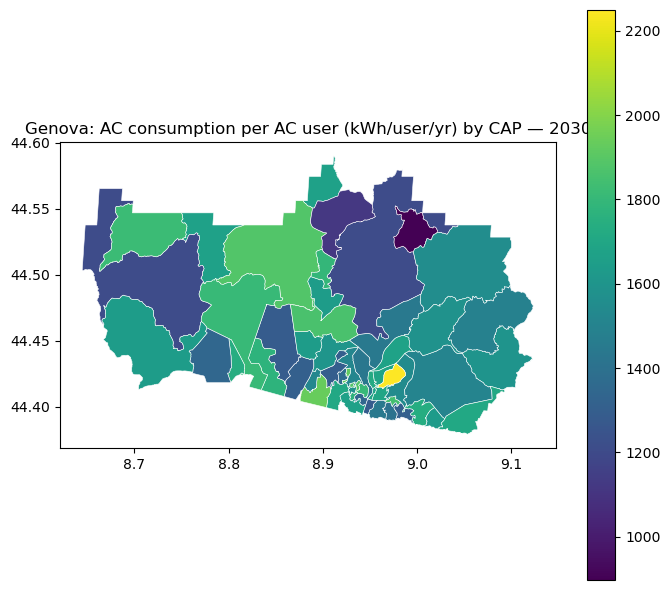

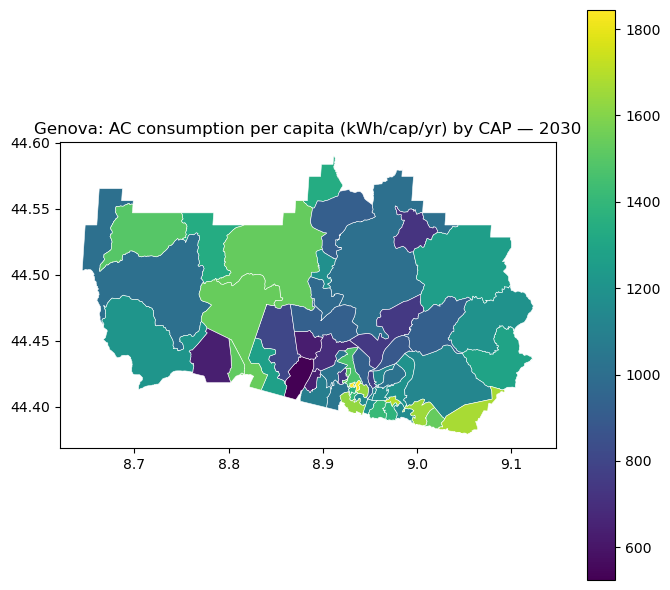


==== CAP-level results for year 2040 ====
City pop: 571,244
City AC users: 422,742 (AC share ≈ 0.740)
City total AC electricity: 702.658 GWh/yr
City per-AC-user mean (users-weighted): 1662.144031 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.980000,1986.621826,5097.651505,9.924564e+06,1946.889396,2040
1,34,0.974666,1947.263794,8336.674553,1.582244e+07,1897.931638,2040
2,26,0.962609,1905.837158,11355.971733,2.083339e+07,1834.575805,2040
3,50,0.980000,1833.551270,19233.725601,3.456070e+07,1796.880246,2040
4,67,0.980000,1803.143433,9021.712799,1.594209e+07,1767.080566,2040
5,56,0.902475,1909.439819,9610.856765,1.656163e+07,1723.221197,2040
6,32,0.980000,1756.323242,11919.447277,2.051571e+07,1721.196772,2040
7,6,0.865232,1987.701416,9834.999859,1.691446e+07,1719.822751,2040
8,57,0.930631,1836.445801,7812.885859,1.335264e+07,1709.053472,2040
9,66,0.980000,1725.895386,6521.786644,1.103080e+07,1691.377564,2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.424830,1378.248535,24234.440105,1.418980e+07,585.521910,2040
1,61,0.406480,1727.872803,11003.788871,7.728465e+06,702.345826,2040
2,58,0.501267,1416.215332,26561.424908,1.885601e+07,709.902101,2040
3,52,0.444188,1608.045044,11769.104088,8.406377e+06,714.275022,2040
4,60,0.459689,1689.798584,16287.529104,1.265186e+07,776.782105,2040
5,7,0.854453,947.926697,2885.647788,2.337255e+06,809.958555,2040
6,37,0.573194,1438.379883,8075.945459,6.658379e+06,824.470579,2040
7,41,0.546527,1525.774780,16937.542490,1.412383e+07,833.876954,2040
8,42,0.473045,1813.877075,7388.673108,6.339815e+06,858.045102,2040
9,54,0.663969,1357.752075,20048.646834,1.807395e+07,901.504639,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.760211,1870.232666,26582.223085,3.779383e+07,1421.770751,2040
1,50,0.980000,1833.551270,19233.725601,3.456070e+07,1796.880246,2040
2,47,0.980000,1524.626709,21656.240709,3.235733e+07,1494.134159,2040
3,51,0.594640,2040.752441,25574.830058,3.103539e+07,1213.513181,2040
4,48,0.980000,1483.004639,17011.440910,2.472349e+07,1453.344602,2040
5,45,0.730487,1786.155518,17377.218135,2.267317e+07,1304.764157,2040
6,35,0.819182,1631.335571,16543.735362,2.210839e+07,1336.360107,2040
7,49,0.945622,1378.209106,16017.972441,2.087566e+07,1303.264649,2040
8,26,0.962609,1905.837158,11355.971733,2.083339e+07,1834.575805,2040
9,32,0.980000,1756.323242,11919.447277,2.051571e+07,1721.196772,2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.858750,1683.793579,5.160067,7.461236e+03,1445.957368,2040
1,1,0.852524,1758.226807,10.055313,1.507222e+04,1498.930792,2040
2,5,0.875088,1918.899536,29.075770,4.882422e+04,1679.206535,2040
3,12,0.856725,1567.446777,533.756073,7.167655e+05,1342.870855,2040
4,14,0.857912,1642.420410,1250.464602,1.761969e+06,1409.051752,2040
5,7,0.854453,947.926697,2885.647788,2.337255e+06,809.958555,2040
6,9,0.873381,1179.033569,2565.523388,2.641836e+06,1029.745359,2040
7,38,0.832401,2025.887329,3218.238953,5.427080e+06,1686.350828,2040
8,27,0.850127,1861.958374,3605.748512,5.707545e+06,1582.901497,2040
9,42,0.473045,1813.877075,7388.673108,6.339815e+06,858.045102,2040


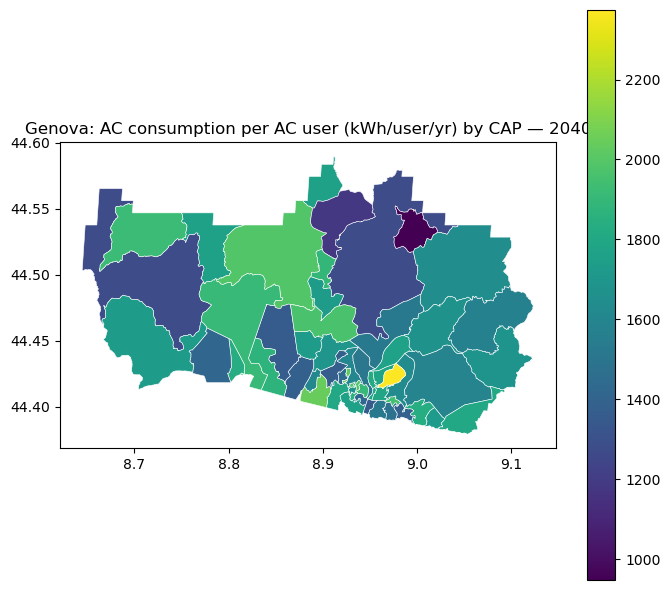

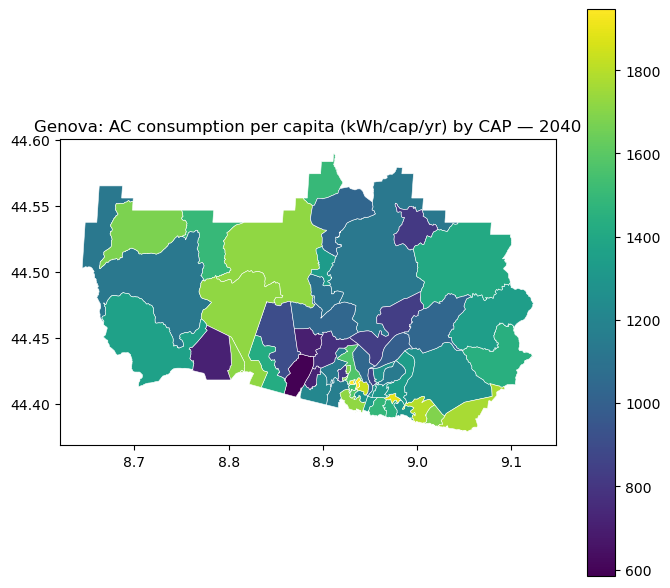


==== CAP-level results for year 2050 ====
City pop: 563,794
City AC users: 417,227 (AC share ≈ 0.740)
City total AC electricity: 725.683 GWh/yr
City per-AC-user mean (users-weighted): 1739.300732 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,29,0.980000,2078.653320,5031.281784,1.024913e+07,2037.080324,2050
1,34,0.974666,2037.714355,8228.133705,1.634182e+07,1986.090702,2050
2,26,0.962609,1994.121582,11208.120445,2.151465e+07,1919.559085,2050
3,50,0.980000,1918.564819,18983.308662,3.569230e+07,1880.193601,2050
4,67,0.980000,1886.537842,8904.252981,1.646225e+07,1848.807124,2050
5,56,0.902475,1998.154541,9485.685709,1.710539e+07,1803.284060,2050
6,32,0.980000,1837.774780,11764.259892,2.118766e+07,1801.019294,2050
7,6,0.865232,2080.104248,9706.702189,1.746986e+07,1799.772584,2050
8,57,0.930631,1921.735474,7711.164522,1.379085e+07,1788.426642,2050
9,66,0.980000,1805.908203,6436.874994,1.139192e+07,1769.790043,2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,53,0.424830,1442.263428,23918.915363,1.465554e+07,612.717406,2050
1,61,0.406480,1808.118652,10860.523034,7.982095e+06,734.964172,2050
2,58,0.501267,1481.885620,26215.603637,1.947349e+07,742.820496,2050
3,52,0.444188,1682.670044,11615.874046,8.681967e+06,747.422607,2050
4,60,0.459689,1768.251587,16075.470612,1.306688e+07,812.846129,2050
5,7,0.854453,991.656494,2840.847371,2.407117e+06,847.323611,2050
6,37,0.573194,1505.224365,7970.799152,6.877090e+06,862.785465,2050
7,41,0.546527,1596.557495,16717.029205,1.458664e+07,872.561645,2050
8,42,0.473045,1898.015747,7292.475019,6.547523e+06,897.846436,2050
9,54,0.663969,1420.668091,19787.600829,1.866523e+07,943.278871,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,55,0.760211,1957.086426,26236.130979,3.903406e+07,1487.797847,2050
1,50,0.980000,1918.564819,18983.308662,3.569230e+07,1880.193601,2050
2,47,0.980000,1595.450562,21374.283273,3.341958e+07,1563.541626,2050
3,51,0.594640,2135.601074,25241.853817,3.205498e+07,1269.913941,2050
4,48,0.980000,1551.856689,16789.957395,2.553450e+07,1520.819575,2050
5,45,0.730487,1869.041138,17150.972403,2.341641e+07,1365.311029,2050
6,35,0.819182,1707.053833,16328.341117,2.283334e+07,1398.387088,2050
7,49,0.945622,1442.162476,15809.423424,2.155995e+07,1363.740358,2050
8,26,0.962609,1994.121582,11208.120445,2.151465e+07,1919.559085,2050
9,32,0.980000,1837.774780,11764.259892,2.118766e+07,1801.019294,2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,11,0.858750,1761.911865,5.072278,7.674568e+03,1513.041500,2050
1,1,0.852524,1839.884766,9.947410,1.560297e+04,1568.546273,2050
2,5,0.875088,2008.081055,28.754267,5.052839e+04,1757.248302,2050
3,12,0.856725,1640.338501,527.007778,7.406140e+05,1405.318970,2050
4,14,0.857912,1718.655151,1226.468684,1.808372e+06,1474.454468,2050
5,7,0.854453,991.656494,2840.847371,2.407117e+06,847.323611,2050
6,9,0.873381,1233.567993,2528.586825,2.724236e+06,1077.374757,2050
7,38,0.832401,2119.782959,3176.338528,5.604680e+06,1764.509653,2050
8,27,0.850127,1948.145264,3558.802834,5.893987e+06,1656.171263,2050
9,42,0.473045,1898.015747,7292.475019,6.547523e+06,897.846436,2050


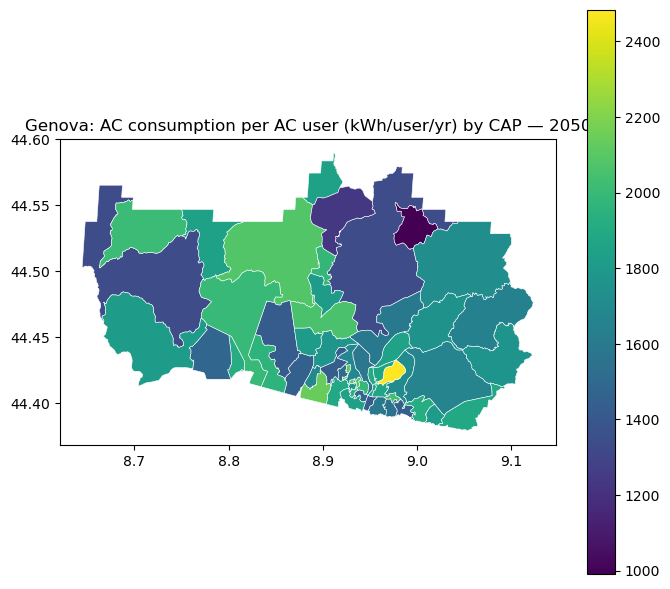

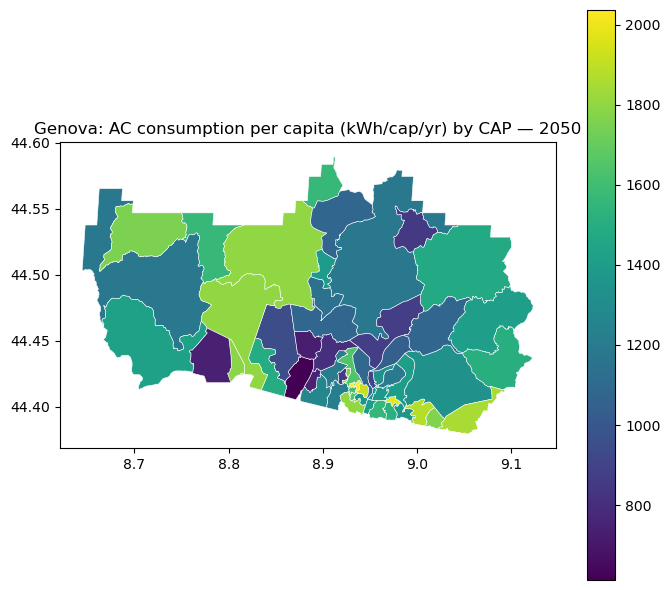

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap_ac_consumption_map.geojson


In [9]:
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
cap_per_user_by_year = {}
cap_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # year-specific population (changes over time) 
    pop_grid = pop_for_year(year)  

    # inputs for this year
    coverage_map = _cov_for_year(year)  # AC penetration map
    H_year = _get_H_for_year(year)      # hazard index
    per_user_city = float(per_user_city_by_year[year])  # kWh per AC user (city)

    # citywide AC share from the map (pop-weighted)
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # target AC share from NB5, if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"AC share from map (city pop-weighted): {ac_city_map:.3f}")
    print(f"AC share from NB5 (target): {ac_city_target:.3f}")

    # CAP-level hazard index (pop-weighted) for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("cap_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("cap_id")
             .reset_index(drop=True))

    H_city = (float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean()))

    # fixed eps per CAP (same CAP is always "high" or "low" across years)
    eps = cap_H["cap_id"].map(eps_by_cap).to_numpy(float)

    cap_draws = cap_H.copy()
    ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0) # spread around the city mean, proportional to local heat

    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # paint to grid (cap_id -> kWh/user)
    lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

    per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # scale so that users-weighted city mean equals per_user_city exactly
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # totals
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id","per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # diagnostics
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print("Per-user mean (city):", per_user_mean_city)
    print("AC share from map: ", ac_share_from_map)
    print("City total GWh: ", city_total_gwh)

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                  .agg(pop_cap=("pop","sum"), kwh_cap=("kwh","sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    per_user_map_by_year[year] = per_user_map
    kwh_tot_map_by_year[year] = kwh_tot_map
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)

# CAP-level consumption tables and maps over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
cap_ids = cap_on_ref  # pop_grid will be year-specific inside the loop

def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall","year"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n==== CAP-level results for year {year_map} ====")

    # year-specific population
    pop_grid = pop_for_year(year_map) # change over time 

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # matched pixel universe: within city, with CAP, and finite for all needed layers
    CAP_PIX = (CITY_MASK & (cap_ids > 0) &
               np.isfinite(pop_grid) &
               np.isfinite(coverage_map) &
               np.isfinite(kwh_tot_map))

    # users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop": pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop","sum"), users_cap=("users","sum")))
    cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0, cap_pop_users["users_cap"] / cap_pop_users["pop_cap"], np.nan)

    # energy totals by CAP (sum of pixel kWh)
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = (df_kwh.groupby("cap_id", as_index=False)
                  .agg(kwh_cap=("kwh","sum")))

    # merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0, cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # city checks on the same matched universe
    city_pop = float(np.nansum(pop_grid[CAP_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

    # ranks for this year
    show_rank(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank(cap_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # join to CAP polygons (cap_4326 loaded earlier)
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # maps for this year
    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

# save all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id","geometry","year", "kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**


==== Municipio-level results for year 2030 ====
City diagnostics by universe:
[ALL FUA] per-user=1574.513527 AC-share=0.704 total=639.346 GWh pop=576,550 users=406,059
[Municipi-only (muni_on_ref>0)] per-user=1587.285351 AC-share=0.698 total=598.564 GWh pop=539,994 users=377,099
[Outside Municipi (muni_id==0)] per-user=1408.209192 AC-share=0.792 total=40.782 GWh pop=36,556 users=28,960

Check: in + out should equal all
users: 406059.072265625 vs 406059.09375
GWh:  639.345536 vs 639.345536

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1574.5136150158223
City total GWh: 639.3455432545917

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,4,0.893146,1575.863527,66699.290056,9.387763e+07,1407.475631,2030
1,2,0.861169,1629.023962,67664.634151,9.492436e+07,1402.865256,2030
2,6,0.931461,1472.850685,70074.904718,9.613597e+07,1371.902939,2030
3,1,0.633954,1717.717797,45902.595740,4.998585e+07,1088.954689,2030
4,8,0.642676,1586.797322,51797.884707,5.282328e+07,1019.796176,2030
5,3,0.575818,1689.655134,52716.844718,5.129004e+07,972.934561,2030
6,7,0.586870,1518.360937,70396.979729,6.272942e+07,891.081111,2030
7,5,0.558567,1533.665398,54548.316493,4.672911e+07,856.655325,2030
8,9,0.491759,1699.726778,59900.125865,5.006787e+07,835.855892,2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.491759,1699.726778,59900.125865,5.006787e+07,835.855892,2030
1,5,0.558567,1533.665398,54548.316493,4.672911e+07,856.655325,2030
2,7,0.586870,1518.360937,70396.979729,6.272942e+07,891.081111,2030
3,3,0.575818,1689.655134,52716.844718,5.129004e+07,972.934561,2030
4,8,0.642676,1586.797322,51797.884707,5.282328e+07,1019.796176,2030
5,1,0.633954,1717.717797,45902.595740,4.998585e+07,1088.954689,2030
6,6,0.931461,1472.850685,70074.904718,9.613597e+07,1371.902939,2030
7,2,0.861169,1629.023962,67664.634151,9.492436e+07,1402.865256,2030
8,4,0.893146,1575.863527,66699.290056,9.387763e+07,1407.475631,2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.931461,1472.850685,70074.904718,9.613597e+07,1371.902939,2030
1,2,0.861169,1629.023962,67664.634151,9.492436e+07,1402.865256,2030
2,4,0.893146,1575.863527,66699.290056,9.387763e+07,1407.475631,2030
3,7,0.586870,1518.360937,70396.979729,6.272942e+07,891.081111,2030
4,8,0.642676,1586.797322,51797.884707,5.282328e+07,1019.796176,2030
5,3,0.575818,1689.655134,52716.844718,5.129004e+07,972.934561,2030
6,9,0.491759,1699.726778,59900.125865,5.006787e+07,835.855892,2030
7,1,0.633954,1717.717797,45902.595740,4.998585e+07,1088.954689,2030
8,5,0.558567,1533.665398,54548.316493,4.672911e+07,856.655325,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.558567,1533.665398,54548.316493,4.672911e+07,856.655325,2030
1,1,0.633954,1717.717797,45902.595740,4.998585e+07,1088.954689,2030
2,9,0.491759,1699.726778,59900.125865,5.006787e+07,835.855892,2030
3,3,0.575818,1689.655134,52716.844718,5.129004e+07,972.934561,2030
4,8,0.642676,1586.797322,51797.884707,5.282328e+07,1019.796176,2030
5,7,0.586870,1518.360937,70396.979729,6.272942e+07,891.081111,2030
6,4,0.893146,1575.863527,66699.290056,9.387763e+07,1407.475631,2030
7,2,0.861169,1629.023962,67664.634151,9.492436e+07,1402.865256,2030
8,6,0.931461,1472.850685,70074.904718,9.613597e+07,1371.902939,2030


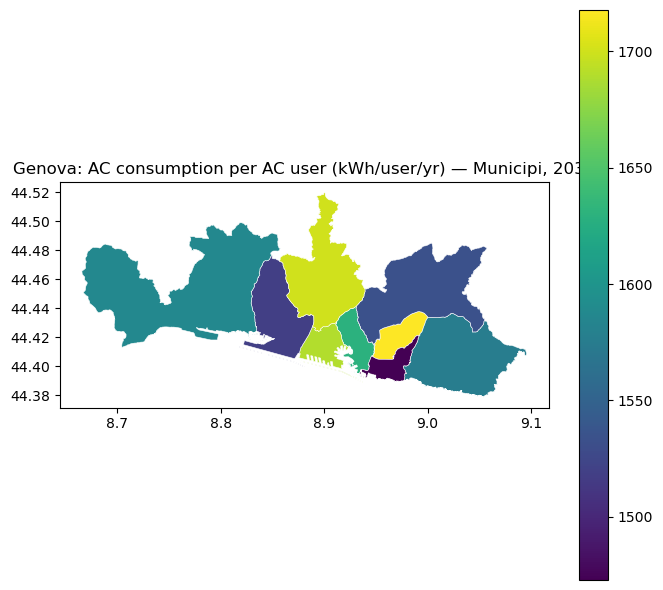

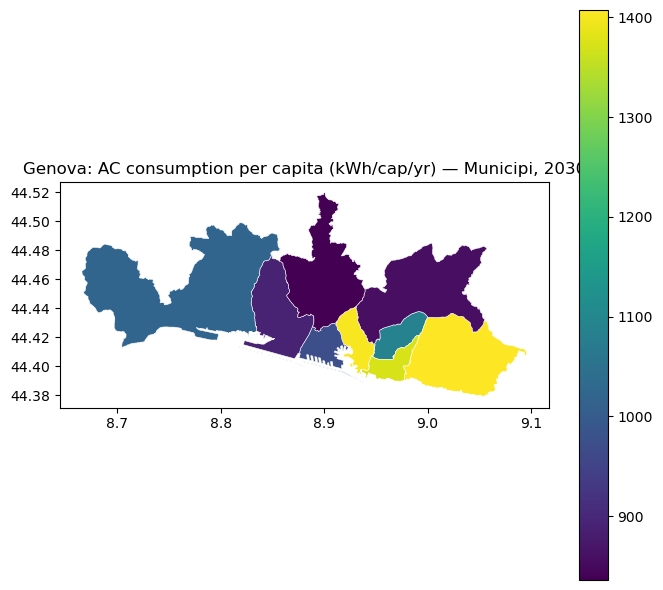


==== Municipio-level results for year 2040 ====
City diagnostics by universe:
[ALL FUA] per-user=1662.144135 AC-share=0.739 total=702.658 GWh pop=572,418 users=422,742
[Municipi-only (muni_on_ref>0)] per-user=1675.771995 AC-share=0.732 total=657.321 GWh pop=536,147 users=392,250
[Outside Municipi (muni_id==0)] per-user=1486.839522 AC-share=0.841 total=45.337 GWh pop=36,270 users=30,492

Check: in + out should equal all
users: 422742.044921875 vs 422742.0625
GWh:  702.65826 vs 702.65824

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1662.1440876610175
City total GWh: 702.6581940732111

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,4,0.930070,1660.745597,66224.176875,1.022905e+08,1544.610312,2040
1,2,0.893106,1718.873954,67182.644509,1.031346e+08,1535.137473,2040
2,6,0.954151,1556.100531,69575.746240,1.033030e+08,1484.755308,2040
3,1,0.672692,1812.932868,45575.621918,5.558158e+07,1219.546182,2040
4,8,0.681991,1675.154103,51428.522869,5.875402e+07,1142.440415,2040
5,3,0.610700,1783.235061,52341.331345,5.700084e+07,1089.021505,2040
6,7,0.622485,1602.895032,69895.525368,6.974023e+07,997.778146,2040
7,5,0.592228,1618.818726,54159.741621,5.192351e+07,958.710365,2040
8,9,0.521047,1793.972012,59473.521655,5.559250e+07,934.743684,2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.521047,1793.972012,59473.521655,5.559250e+07,934.743684,2040
1,5,0.592228,1618.818726,54159.741621,5.192351e+07,958.710365,2040
2,7,0.622485,1602.895032,69895.525368,6.974023e+07,997.778146,2040
3,3,0.610700,1783.235061,52341.331345,5.700084e+07,1089.021505,2040
4,8,0.681991,1675.154103,51428.522869,5.875402e+07,1142.440415,2040
5,1,0.672692,1812.932868,45575.621918,5.558158e+07,1219.546182,2040
6,6,0.954151,1556.100531,69575.746240,1.033030e+08,1484.755308,2040
7,2,0.893106,1718.873954,67182.644509,1.031346e+08,1535.137473,2040
8,4,0.930070,1660.745597,66224.176875,1.022905e+08,1544.610312,2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.954151,1556.100531,69575.746240,1.033030e+08,1484.755308,2040
1,2,0.893106,1718.873954,67182.644509,1.031346e+08,1535.137473,2040
2,4,0.930070,1660.745597,66224.176875,1.022905e+08,1544.610312,2040
3,7,0.622485,1602.895032,69895.525368,6.974023e+07,997.778146,2040
4,8,0.681991,1675.154103,51428.522869,5.875402e+07,1142.440415,2040
5,3,0.610700,1783.235061,52341.331345,5.700084e+07,1089.021505,2040
6,9,0.521047,1793.972012,59473.521655,5.559250e+07,934.743684,2040
7,1,0.672692,1812.932868,45575.621918,5.558158e+07,1219.546182,2040
8,5,0.592228,1618.818726,54159.741621,5.192351e+07,958.710365,2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.592228,1618.818726,54159.741621,5.192351e+07,958.710365,2040
1,1,0.672692,1812.932868,45575.621918,5.558158e+07,1219.546182,2040
2,9,0.521047,1793.972012,59473.521655,5.559250e+07,934.743684,2040
3,3,0.610700,1783.235061,52341.331345,5.700084e+07,1089.021505,2040
4,8,0.681991,1675.154103,51428.522869,5.875402e+07,1142.440415,2040
5,7,0.622485,1602.895032,69895.525368,6.974023e+07,997.778146,2040
6,4,0.930070,1660.745597,66224.176875,1.022905e+08,1544.610312,2040
7,2,0.893106,1718.873954,67182.644509,1.031346e+08,1535.137473,2040
8,6,0.954151,1556.100531,69575.746240,1.033030e+08,1484.755308,2040


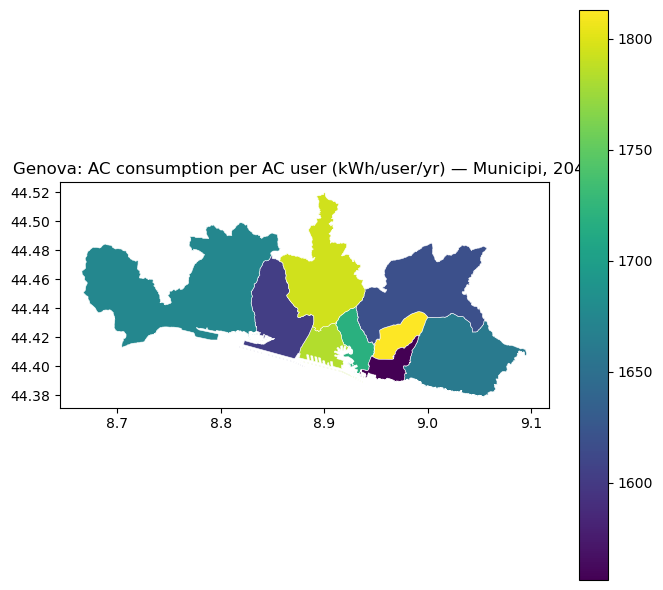

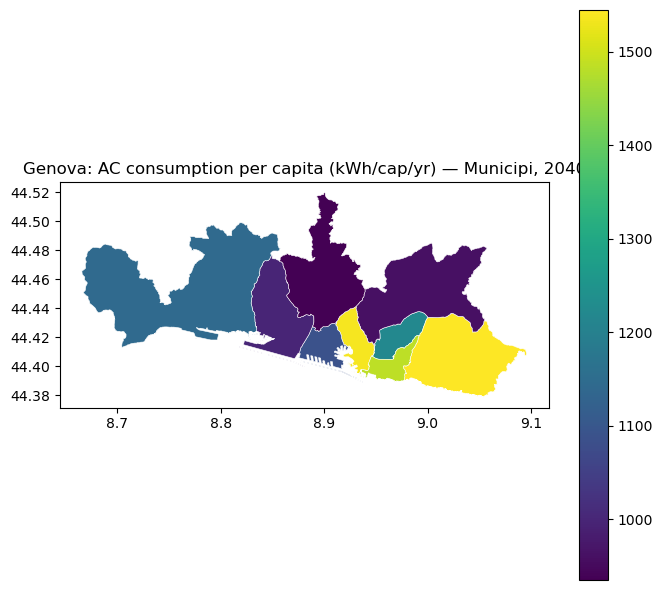


==== Municipio-level results for year 2050 ====
City diagnostics by universe:
[ALL FUA] per-user=1739.300761 AC-share=0.739 total=725.683 GWh pop=564,952 users=417,227
[Municipi-only (muni_on_ref>0)] per-user=1753.555448 AC-share=0.732 total=678.876 GWh pop=529,167 users=387,142
[Outside Municipi (muni_id==0)] per-user=1555.866285 AC-share=0.841 total=46.808 GWh pop=35,785 users=30,085

Check: in + out should equal all
users: 417227.087890625 vs 417227.125
GWh:  725.683436 vs 725.683456

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1739.3007728173418
City total GWh: 725.6834440486175

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,4,0.930070,1737.746386,65361.958996,1.056397e+08,1616.226483,2050
1,2,0.893106,1798.619970,66307.947828,1.065144e+08,1606.359148,2050
2,6,0.954151,1628.380315,68669.892095,1.066939e+08,1553.721164,2050
3,1,0.672692,1897.088522,44982.241923,5.740440e+07,1276.157047,2050
4,8,0.681991,1752.920185,50758.846754,6.068097e+07,1195.475742,2050
5,3,0.610700,1866.064983,51659.863689,5.887188e+07,1139.605716,2050
6,7,0.622485,1677.294367,68985.506779,7.202712e+07,1044.090598,2050
7,5,0.592228,1693.947314,53454.563255,5.362581e+07,1003.203532,2050
8,9,0.521047,1877.311288,58699.260284,5.741770e+07,978.167305,2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.521047,1877.311288,58699.260284,5.741770e+07,978.167305,2050
1,5,0.592228,1693.947314,53454.563255,5.362581e+07,1003.203532,2050
2,7,0.622485,1677.294367,68985.506779,7.202712e+07,1044.090598,2050
3,3,0.610700,1866.064983,51659.863689,5.887188e+07,1139.605716,2050
4,8,0.681991,1752.920185,50758.846754,6.068097e+07,1195.475742,2050
5,1,0.672692,1897.088522,44982.241923,5.740440e+07,1276.157047,2050
6,6,0.954151,1628.380315,68669.892095,1.066939e+08,1553.721164,2050
7,2,0.893106,1798.619970,66307.947828,1.065144e+08,1606.359148,2050
8,4,0.930070,1737.746386,65361.958996,1.056397e+08,1616.226483,2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.954151,1628.380315,68669.892095,1.066939e+08,1553.721164,2050
1,2,0.893106,1798.619970,66307.947828,1.065144e+08,1606.359148,2050
2,4,0.930070,1737.746386,65361.958996,1.056397e+08,1616.226483,2050
3,7,0.622485,1677.294367,68985.506779,7.202712e+07,1044.090598,2050
4,8,0.681991,1752.920185,50758.846754,6.068097e+07,1195.475742,2050
5,3,0.610700,1866.064983,51659.863689,5.887188e+07,1139.605716,2050
6,9,0.521047,1877.311288,58699.260284,5.741770e+07,978.167305,2050
7,1,0.672692,1897.088522,44982.241923,5.740440e+07,1276.157047,2050
8,5,0.592228,1693.947314,53454.563255,5.362581e+07,1003.203532,2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,5,0.592228,1693.947314,53454.563255,5.362581e+07,1003.203532,2050
1,1,0.672692,1897.088522,44982.241923,5.740440e+07,1276.157047,2050
2,9,0.521047,1877.311288,58699.260284,5.741770e+07,978.167305,2050
3,3,0.610700,1866.064983,51659.863689,5.887188e+07,1139.605716,2050
4,8,0.681991,1752.920185,50758.846754,6.068097e+07,1195.475742,2050
5,7,0.622485,1677.294367,68985.506779,7.202712e+07,1044.090598,2050
6,4,0.930070,1737.746386,65361.958996,1.056397e+08,1616.226483,2050
7,2,0.893106,1798.619970,66307.947828,1.065144e+08,1606.359148,2050
8,6,0.954151,1628.380315,68669.892095,1.066939e+08,1553.721164,2050


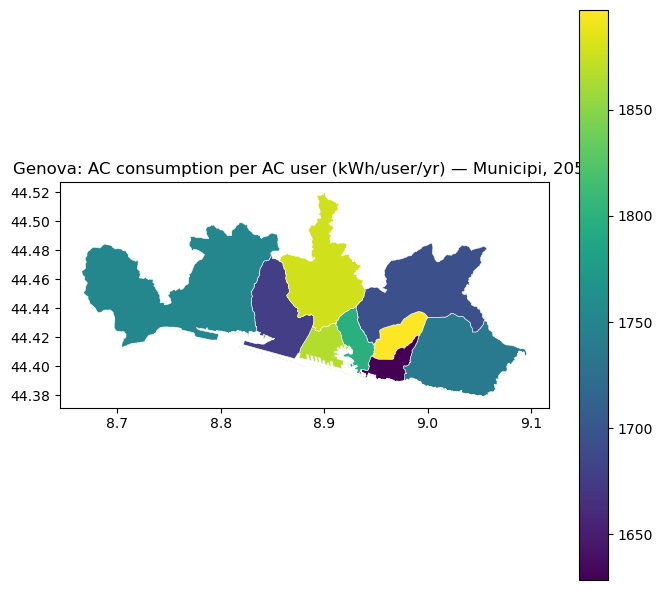

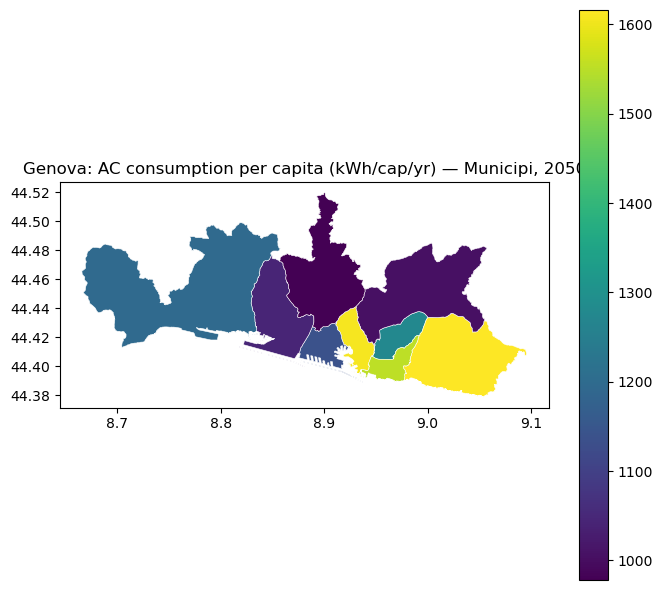

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_ac_consumption_map.geojson


In [10]:
# Municipio-level AC electricity: per-user, per-capita, totals over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."
# pop_grid will be year-specific inside the loop

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni", "pop_muni","kwh_muni","kwh_pc_overall","year"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n==== Municipio-level results for year {year_map} ====")

    # year-specific population
    pop_grid = pop_for_year(year_map)  # NEW

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.6f} AC-share={users/pop:.3f} "
              f"total={kwh:.3f} GWh pop={pop:,.0f} users={users:,.0f}")
        return per_user, users, kwh

    # universes (keep id==0 as "outside" bucket)
    mask_all = CITY_MASK
    mask_in = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in, u_in, k_in = city_diag(mask_in, "Municipi-only (muni_on_ref>0)")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

    print("\nCheck: in + out should equal all")
    print("users:", u_in + u_out, "vs", u_all)
    print("GWh: ", k_in + k_out, "vs", k_all)

    # Build pixel to Municipio table over the full city mask (includes muni_id==0)
    valid_all = (CITY_MASK & np.isfinite(per_user_map) & np.isfinite(kwh_tot_map) & np.isfinite(pop_grid) & np.isfinite(coverage_map))
    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int), # includes 0
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # totals by municipio
    muni_tbl_all = (df.groupby("muni_id", as_index=False)
                    .agg(pop_muni=("pop","sum"), users_muni=("users","sum"), kwh_muni=("kwh","sum"))
                    .merge(per_user_by_muni, on="muni_id", how="left"))

    # rates
    muni_tbl_all["ac_share_muni"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["kwh_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["year"] = year_map
    all_muni_tbl.append(muni_tbl_all)

    # city diagnostics from grouped table
    users_sum = float(muni_tbl_all["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"]) / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
    print("\nFrom groupby (includes muni_id=0):")
    print("Users-weighted per-user mean (city):", per_user_from_groups)
    print("City total GWh:", kwh_sum)

    # tables and maps for Municipi only (exclude id==0 for reporting)
    muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni", k=10, title=f"Total kWh, {year_map}")

    # map join
    muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

# saving all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
 .assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
 .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id","geometry","year", "kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the “per AC user” and “per capita” maps look different?
The two maps use different denominators. The per-AC-user map shows the average annual AC electricity use only among households that actually own AC in each CAP. We construct this by drawing CAP-level values around the city-wide mean (from the NUTS data) with a spread proportional to local heat (hazard), and then rescaling so that the city-wide users-weighted mean exactly matches the NUTS value. The per-capita map divides the same total AC electricity by the entire population in each CAP, not just AC users. It is approximately kWh per capita ≈ AC ownership share × kWh per AC user. As a result, a CAP with low ownership but high usage among users will still look low on the per-capita map, while a CAP with high ownership looks high per capita even if individual users are not especially intensive. Municipi vs CAP: Municipio values are simply population-weighted aggregates of the CAPs (or more precisely, pixel-level data) that fall inside each Municipio. Rankings of total kWh differ from per-capita rankings because total consumption is total kWh=kWh per capita×population, so large Municipi with moderate per-capita use can still have very high totals.
</blockquote>